# Pneumonia Detection from Chest X-Rays
### CNN transfer learning with MobileNetV2 (TensorFlow / Keras)

---

## Project Overview

**Objective.** Build an image classifier that labels a chest X-ray as `NORMAL` or `PNEUMONIA`.

**Dataset.** 5,856 chest X-ray images in `train`, `val` and `test` folders (5,216 / 16 / 624 images) with two classes.

**Approach.**
- MobileNetV2 pretrained on ImageNet, adapted to single-channel (grayscale) input
- Frozen backbone with a new classification head (`GlobalAveragePooling2D` → `Dense(256)` → `Dropout(0.3)` → `Dense(1, sigmoid)`)
- Class weights to handle the NORMAL / PNEUMONIA imbalance, light data augmentation, early stopping

**Headline results** (test set, taken from the outputs below):

| Metric | Value |
|---|---|
| Accuracy | 0.9054 |
| ROC-AUC | 0.962 |
| Sensitivity (PNEUMONIA recall) | 0.9667 |
| Specificity (NORMAL recall) | 0.8034 |
| PNEUMONIA precision / F1 | 0.89 / 0.93 |

> **Read this with care:** the test set was also passed as `validation_data` during training, so it influenced early stopping and the choice of the best epoch (details in sections 8 and 11). These numbers are best treated as validation-level performance, not a fully independent test.

## Contents

1. Environment Setup
2. Data Loading
3. Exploratory Data Analysis
4. Data Preparation
5. Input Pipeline (`tf.data`)
6. Data Augmentation
7. Model Architecture
8. Training
9. Saving the Model
10. Training Curves
11. Model Evaluation
12. Single-Image Inference
13. Conclusion

---
## 1. Environment Setup

**What this cell does:** imports every library used in the notebook and prints the TensorFlow version and the GPU devices that are visible.

**Why:** the imports are grouped by role, so it is clear where each tool is used:
- `os`, `random`, `PIL` – file handling and reading images
- `numpy`, `pandas` – numerical work and the image metadata table
- `matplotlib`, `seaborn` – plots
- `tensorflow` / `keras` – data pipeline, model and training
- `sklearn` – train/validation split helper and evaluation metrics (classification report, confusion matrix, ROC / AUC)

The GPU check matters because training a CNN on 5,216 images is much faster on a GPU.

In [1]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_curve,
    roc_auc_score,
    precision_score,
    recall_score
)

print("TensorFlow:", tf.__version__)
print("GPU:", tf.config.list_physical_devices("GPU"))

TensorFlow: 2.20.0
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


**Observations**
- TensorFlow **2.20.0** is used.
- One GPU (`/physical_device:GPU:0`) is detected, so training runs on GPU.

---
## 2. Data Loading

The dataset is stored as a zip file (`Chest-Xray-2.zip`) in Google Drive and is extracted into the Colab runtime at `/content/chest-xray_dataset`.

The `USE_ZIP` flag controls this step:
- `USE_ZIP = True` (current setting) mounts Google Drive and extracts the zip.
- `USE_ZIP = False` skips mounting and unzipping and uses a folder that is already extracted, so **Run all** works without a login prompt.

In [2]:
import zipfile

USE_ZIP = True

zip_path = "/content/drive/MyDrive/Chest-Xray-2.zip"   # change if you use a zip
extract_path = "/content/chest-xray_dataset"

if USE_ZIP:
    from google.colab import drive
    drive.mount('/content/drive')

    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extract_path)
    print("Dataset extracted successfully!")
    print("Location:", extract_path)
else:
    print("Skipping unzip – using the already extracted folder.")

Mounted at /content/drive
Dataset extracted successfully!
Location: /content/chest-xray_dataset


**Observations**
- Google Drive was mounted and the archive extracted without errors.
- The images are now available under `/content/chest-xray_dataset`.

---
## 3. Exploratory Data Analysis

Before building anything, we check the structure, size, balance and quality of the data. The findings from this section drive several later decisions (class weights, resizing, augmentation, how to use the validation set).

### 3.1 Directory Structure Validation

**What:** confirm that `train`, `val` and `test` exist, read the class folders of each split, and make sure all splits contain the same classes.

**Why:** a missing folder or a mismatched class name would silently corrupt the labels later. `get_classes()` ignores hidden or system folders (`.ipynb_checkpoints`, `__MACOSX`, ...) so they are not mistaken for classes. The `assert` statements stop the notebook immediately if anything is wrong.

In [3]:
dataset_dir = "/content/chest-xray_dataset/chest_xray"
splits = ["train", "val", "test"]

# Every split folder must exist
for split in splits:
    split_path = os.path.join(dataset_dir, split)
    assert os.path.isdir(split_path), f"Missing folder: {split_path}"


def get_classes(split):
    split_path = os.path.join(dataset_dir, split)
    return sorted(
        c for c in os.listdir(split_path)
        if os.path.isdir(os.path.join(split_path, c))
        and not c.startswith((".", "__"))          # ignore .ipynb_checkpoints, __MACOSX, ...
    )


classes = get_classes("train")

# Every split must contain the same class folders
for split in splits:
    assert get_classes(split) == classes, f"Class folders in '{split}' differ from 'train'"

print("Splits:", splits)
print("Number of classes:", len(classes))
print("classes:", classes)

Splits: ['train', 'val', 'test']
Number of classes: 2
classes: ['NORMAL', 'PNEUMONIA']


**Observations**
- Three splits are present: `train`, `val`, `test`.
- The problem is binary: **2 classes**, `NORMAL` and `PNEUMONIA`.
- All assertions passed, so every split has the same class folders.

### 3.2 Image Count per Split and Class

**What:** count the image files (`.jpg`, `.jpeg`, `.png`, `.bmp`, `.webp`) in each class folder of each split and arrange the counts in a table with row totals.

**Why:** the size and balance of each split determine how we train and how far we can trust the evaluation.

In [4]:
image_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

rows = []

for split in splits:
    for cls in classes:
        class_path = os.path.join(dataset_dir, split, cls)

        count = sum(
            1
            for file in os.listdir(class_path)
            if file.lower().endswith(image_extensions)
        )

        rows.append({"split": split, "diagnosis": cls, "Image_Count": count})

class_counts_df = pd.DataFrame(rows)

counts_table = class_counts_df.pivot(
    index="split", columns="diagnosis", values="Image_Count"
).loc[splits]
counts_table["Total"] = counts_table.sum(axis=1)

counts_table

diagnosis,NORMAL,PNEUMONIA,Total
split,,,
train,1341,3875,5216
val,8,8,16
test,234,390,624


**Observations**

| Split | NORMAL | PNEUMONIA | Total |
|---|---|---|---|
| train | 1341 | 3875 | 5216 |
| val | 8 | 8 | 16 |
| test | 234 | 390 | 624 |

- The training set holds about 89% of all images and the test set about 11%.
- The **validation folder has only 16 images** (0.3% of the data). That is too small to give a stable validation signal. This comes up again in sections 4 and 8.
- PNEUMONIA is the majority class in both `train` and `test`.

### 3.3 Dataset Statistics

**What:** print the overall image count, the per-split counts and the imbalance ratio (majority class ÷ minority class) of the training set.

**Why:** one number for the imbalance makes it easy to decide whether corrective measures such as class weights are needed.

In [5]:
print("Total images:", class_counts_df["Image_Count"].sum())
print("Number of classes:", len(classes))

for split in splits:
    n = class_counts_df.loc[class_counts_df["split"] == split, "Image_Count"].sum()
    print(f"{split:>5} images: {n}")

train_counts = class_counts_df[class_counts_df["split"] == "train"].set_index("diagnosis")["Image_Count"]
print("\nTrain imbalance ratio (majority / minority): %.2f" % (train_counts.max() / train_counts.min()))

Total images: 5856
Number of classes: 2
train images: 5216
  val images: 16
 test images: 624

Train imbalance ratio (majority / minority): 2.89


**Observations**
- The dataset contains **5,856 images** in total (5,216 train, 16 val, 624 test).
- The training set has an **imbalance ratio of 2.89**: there are almost three PNEUMONIA images for every NORMAL one.
- This is enough to bias a model towards predicting PNEUMONIA, so it is handled with class weights in section 4.5.

### 3.4 Corrupted Image Check

**What:** open every image with PIL and call `img.verify()`. Files that fail are collected in `corrupted_images`, and a `set` version is kept for fast lookups.

**Why:** a single unreadable file would crash the input pipeline in the middle of a training epoch. Checking once up front is cheaper than debugging it later. The set is reused to skip bad files when sampling images and building the DataFrame.

In [6]:
corrupted_images = []

for split in splits:
    for cls in classes:
        class_path = os.path.join(dataset_dir, split, cls)

        for image_name in os.listdir(class_path):

            if not image_name.lower().endswith(image_extensions):
                continue

            image_path = os.path.join(class_path, image_name)

            try:
                with Image.open(image_path) as img:
                    img.verify()

            except Exception:
                corrupted_images.append(image_path)

corrupted_set = set(corrupted_images)

print("Corrupted images:", len(corrupted_images))

if corrupted_images:
    print("\nExamples:")
    for path in corrupted_images[:10]:
        print(path)

Corrupted images: 0


**Observations**
- **0 corrupted images** were found, so no file has to be removed.

### 3.5 Class Distribution per Split

**What:** a grouped bar chart of the number of images per class in each split.

**Why:** the counts above are precise but a chart makes the imbalance and the tiny validation split easy to see at a glance.

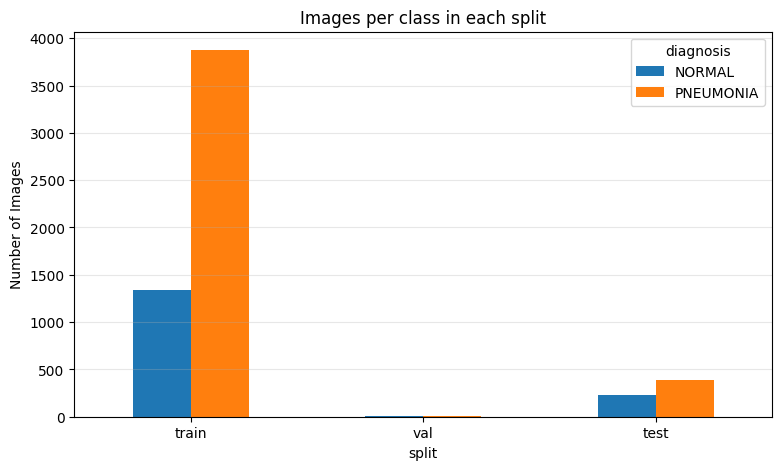

In [7]:
counts_table[classes].plot(kind="bar", figsize=(9, 5))

plt.xticks(rotation=0)
plt.xlabel("split")
plt.ylabel("Number of Images")
plt.title("Images per class in each split")
plt.legend(title="diagnosis")
plt.grid(axis="y", alpha=0.3)

plt.show()

**Observations**
- In `train` the PNEUMONIA bar is nearly three times as tall as the NORMAL bar.
- `test` has the same direction of imbalance, but it is less pronounced than in `train`.
- The `val` bars are almost invisible next to the other splits.

### 3.6 Visual Inspection of Sample Images

**What:** display 12 random training X-rays in a 3 × 4 grid, alternating between NORMAL and PNEUMONIA.

**Why:** looking at the raw data is the quickest way to spot quality problems and to understand what the model will have to learn. Corrupted files are excluded from the sampling. The `random` module is not seeded here, so a different sample appears on every run.

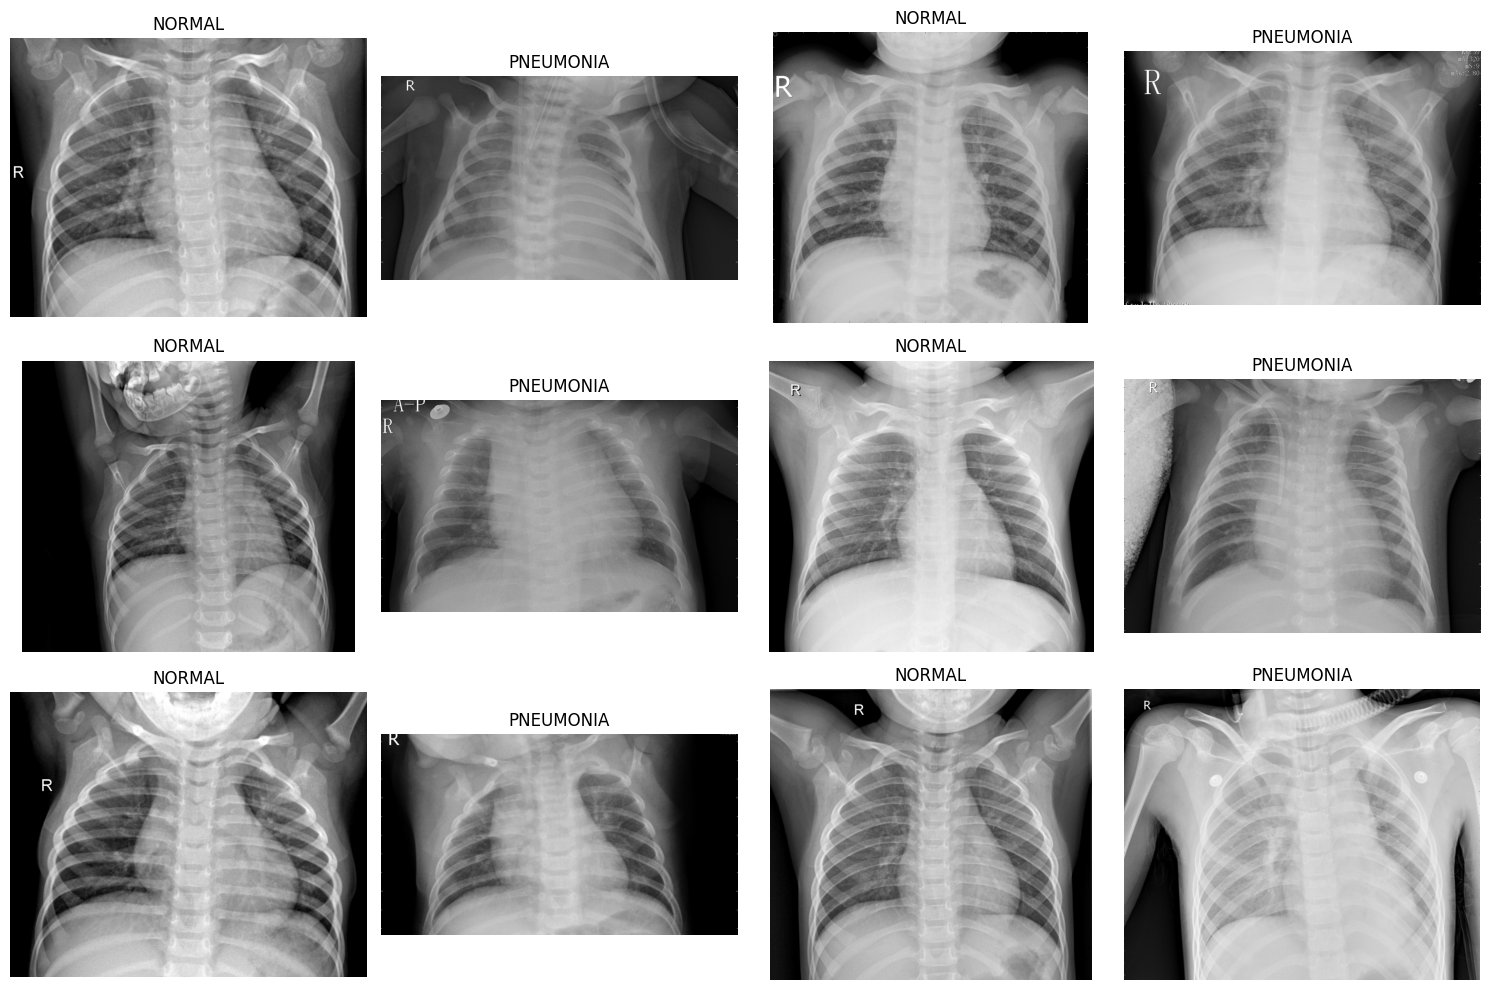

In [8]:
plt.figure(figsize=(15, 10))

for i in range(12):
    diagnosis = classes[i % len(classes)]          # alternate NORMAL / PNEUMONIA
    class_path = os.path.join(dataset_dir, "train", diagnosis)

    images = [
        f for f in os.listdir(class_path)
        if f.lower().endswith(image_extensions)
        and os.path.join(class_path, f) not in corrupted_set
    ]

    image_name = random.choice(images)
    image_path = os.path.join(class_path, image_name)

    image = Image.open(image_path)

    plt.subplot(3, 4, i + 1)
    plt.imshow(image, cmap="gray")
    plt.title(diagnosis)
    plt.axis("off")

plt.tight_layout()
plt.show()

**Observations**
- The X-rays are frontal chest views with clearly different **aspect ratios, framing, brightness and contrast**.
- Several images contain non-anatomical content such as laterality markers ("R"), text labels and what look like tubes or monitoring leads.
- The difference between classes is not always obvious to the eye. In this sample the PNEUMONIA images tend to look hazier than the NORMAL ones.
- The images have a single grayscale channel, which is why the model is built for 1-channel input in section 7.
- **Caution:** markers and devices can act as shortcuts that a model learns instead of the lungs themselves. This is worth checking in future work (for example with Grad-CAM).

### 3.7 Image Size Analysis

**What:** read the width and height of the first 50 training images of each class (100 images in total) and summarise them with `describe()`.

**Why:** the network needs a fixed input size, so we need to know how much the raw sizes vary before choosing one. Only a sample is read because opening all files just for their size is slow; the sample is the first 50 files per class, not a random draw.

In [9]:
sizes = []

for cls in classes:
    class_path = os.path.join(dataset_dir, "train", cls)

    images = [
        f for f in os.listdir(class_path)
        if f.lower().endswith(image_extensions)
    ]

    for image_name in images[:50]:
        image_path = os.path.join(class_path, image_name)

        try:
            with Image.open(image_path) as img:
                sizes.append(img.size)
        except:
            pass

sizes_df = pd.DataFrame(sizes, columns=["Width", "Height"])

sizes_df.describe()

,Width,Height
count,100.000000,100.000000
mean,1463.870000,1120.910000
std,300.359705,339.573205
min,824.000000,568.000000
25%,1247.000000,832.000000
50%,1452.000000,1134.000000
75%,1661.000000,1386.000000
max,2222.000000,2184.000000


**Observations**
- Widths average about 1,464 px (min 824, max 2,222) and heights about 1,121 px (min 568, max 2,184).
- The standard deviation is about 300 px for width and 340 px for height, so the raw sizes vary a lot.
- Every image in the sample is larger than 224 × 224, so resizing to 224 × 224 means downsampling, never upscaling.

### 3.8 EDA Summary

| Finding | Consequence in this notebook |
|---|---|
| Class imbalance of 2.89 : 1 in `train` | Class weights (section 4.5) |
| Only 16 validation images | Optional re-split flag (section 4.3) and a documented workaround in training (section 8) |
| No corrupted files | No cleaning needed, the check is still kept in the pipeline |
| Highly variable image sizes | Resize everything to 224 × 224 (section 5) |
| Variation in framing and contrast | Mild augmentation (section 6) |
| Grayscale images | 1-channel MobileNetV2 with transferred weights (section 7) |

---
## 4. Data Preparation

### 4.1 Building the Metadata DataFrame

**What:** walk through the folders again and build a DataFrame with one row per image: `image_path`, `split` and `diagnosis`. Files that failed the corruption check are skipped.

**Why:** a table of paths and labels is easy to filter, count and inspect, and it feeds directly into `tf.data` later. Keeping the split as a column means the original train / val / test division is preserved.

In [10]:
data = []

for split in splits:
    for cls in classes:
        class_path = os.path.join(dataset_dir, split, cls)

        for file in os.listdir(class_path):

            if file.lower().endswith(image_extensions):

                image_path = os.path.join(class_path, file)

                # skip anything that failed the corruption check
                if image_path in corrupted_set:
                    continue

                data.append({
                    "image_path": image_path,
                    "split": split,
                    "diagnosis": cls
                })

df = pd.DataFrame(data)

print("Total images:", len(df))
print("Total classes:", df["diagnosis"].nunique())

df.head()

Total images: 5856
Total classes: 2


,image_path,split,diagnosis
0,/content/chest-xray_dataset/chest_xray/train/N...,train,NORMAL
1,/content/chest-xray_dataset/chest_xray/train/N...,train,NORMAL
2,/content/chest-xray_dataset/chest_xray/train/N...,train,NORMAL
3,/content/chest-xray_dataset/chest_xray/train/N...,train,NORMAL
4,/content/chest-xray_dataset/chest_xray/train/N...,train,NORMAL


**Observations**
- The DataFrame holds **5,856 rows** and 2 classes, matching the counts from the EDA. No image was dropped.
- The first rows are NORMAL training images, because the table is built class by class.

### 4.2 Label Encoding

**What:** build `class_to_index` and `index_to_class` dictionaries from the sorted class names.

**Why:** models need numeric targets. Sorting the names makes the mapping deterministic, so the same class always gets the same integer. Because this is a binary problem with a sigmoid output, the model's output will be interpreted as the probability of class 1.

In [11]:
classes = sorted(df["diagnosis"].unique())

class_to_index = {
    diagnosis: index
    for index, diagnosis in enumerate(classes)
}

index_to_class = {
    index: diagnosis
    for diagnosis, index in class_to_index.items()
}

**Verify the mapping**

In [12]:
print("Number of classes:", len(classes))

print("\n mappings:")
for i in range(len(classes)):
    print(i, "→", index_to_class[i])

Number of classes: 2

 mappings:
0 → NORMAL
1 → PNEUMONIA


**Observations**
- `0 → NORMAL` and `1 → PNEUMONIA`.
- The sigmoid output of the network is therefore **P(PNEUMONIA)**, and PNEUMONIA is the positive class in all later metrics.

**Attach the numeric label to every row**

Adds a `label` column by mapping `diagnosis` through `class_to_index`.

In [13]:
df["label"] = df["diagnosis"].map(class_to_index)

**Preview the DataFrame**

In [14]:
df.head()

,image_path,split,diagnosis,label
0,/content/chest-xray_dataset/chest_xray/train/N...,train,NORMAL,0
1,/content/chest-xray_dataset/chest_xray/train/N...,train,NORMAL,0
2,/content/chest-xray_dataset/chest_xray/train/N...,train,NORMAL,0
3,/content/chest-xray_dataset/chest_xray/train/N...,train,NORMAL,0
4,/content/chest-xray_dataset/chest_xray/train/N...,train,NORMAL,0


**Observations**
- The new `label` column is present and NORMAL rows carry label `0`.

### 4.3 Train / Validation / Test Split

**What:** create `train_df`, `val_df` and `test_df` by filtering the DataFrame on its `split` column.

**Why:** the dataset already ships with a train / val / test division, so the notebook reuses it (no `train_test_split` is applied here). Reusing the official split keeps the results comparable with other work on the same data and avoids mixing the test images into training.

In [15]:
train_df = df[df["split"] == "train"].reset_index(drop=True)
val_df   = df[df["split"] == "val"].reset_index(drop=True)
test_df  = df[df["split"] == "test"].reset_index(drop=True)

**Optional: re-split the validation set**

The validation folder in this dataset is tiny (16 images), which makes early stopping noisy. Setting `RESPLIT_VAL = True` pools train + val and makes a fresh **stratified 85 / 15 split** (`random_state=42`). The test set stays untouched either way.

In this run `RESPLIT_VAL = False`, so the original folders are used as they are.

In [16]:
RESPLIT_VAL = False

if RESPLIT_VAL:
    trainval_df = pd.concat([train_df, val_df], ignore_index=True)

    train_df, val_df = train_test_split(
        trainval_df,
        test_size=0.15,
        stratify=trainval_df["label"],
        random_state=42
    )

    train_df = train_df.reset_index(drop=True)
    val_df = val_df.reset_index(drop=True)

**Confirm the split sizes**

In [17]:
print("Training:", len(train_df))
print("Validation:", len(val_df))
print("Testing:", len(test_df))

Training: 5216
Validation: 16
Testing: 624


**Observations**
- Training: 5,216, validation: 16, testing: 624 images. These match the folder counts, confirming that the re-split did not run.

### 4.4 Sanity Checks on the Splits

**What:** check that both classes appear in every split and compare the class shares (as fractions) across splits.

**Why:** a split that lacks a class, or has a very different class mix, makes metrics unreliable.

In [18]:
print("Train classes:", train_df["diagnosis"].nunique())
print("Validation classes:", val_df["diagnosis"].nunique())
print("Test classes:", test_df["diagnosis"].nunique())

print("\nClass share per split:")
pd.DataFrame({
    "train": train_df["diagnosis"].value_counts(normalize=True),
    "val":   val_df["diagnosis"].value_counts(normalize=True),
    "test":  test_df["diagnosis"].value_counts(normalize=True),
}).round(3)

Train classes: 2
Validation classes: 2
Test classes: 2

Class share per split:


,train,val,test
diagnosis,,,
NORMAL,0.257,0.5,0.375
PNEUMONIA,0.743,0.5,0.625


**Observations**

| Diagnosis | train | val | test |
|---|---|---|---|
| NORMAL | 0.257 | 0.500 | 0.375 |
| PNEUMONIA | 0.743 | 0.500 | 0.625 |

- Both classes are present in all three splits.
- The class mix is **not the same in every split**: 74.3% PNEUMONIA in `train` versus 62.5% in `test`. Test metrics such as accuracy therefore depend on this mix, which is why precision, recall and AUC are reported later.

**Preview the training DataFrame**

In [19]:
train_df.head(10)

,image_path,split,diagnosis,label
0,/content/chest-xray_dataset/chest_xray/train/N...,train,NORMAL,0
1,/content/chest-xray_dataset/chest_xray/train/N...,train,NORMAL,0
2,/content/chest-xray_dataset/chest_xray/train/N...,train,NORMAL,0
3,/content/chest-xray_dataset/chest_xray/train/N...,train,NORMAL,0
4,/content/chest-xray_dataset/chest_xray/train/N...,train,NORMAL,0
5,/content/chest-xray_dataset/chest_xray/train/N...,train,NORMAL,0
6,/content/chest-xray_dataset/chest_xray/train/N...,train,NORMAL,0
7,/content/chest-xray_dataset/chest_xray/train/N...,train,NORMAL,0
8,/content/chest-xray_dataset/chest_xray/train/N...,train,NORMAL,0
9,/content/chest-xray_dataset/chest_xray/train/N...,train,NORMAL,0


**Observations**
- The first ten training rows are all NORMAL (label `0`), because the table is ordered by class. The training data must therefore be **shuffled** before batching, which is done in section 5.2.

### 4.5 Class Weights

Pneumonia images usually outnumber normal ones about 3 : 1 in the training set. Without correction the model can lean towards always predicting PNEUMONIA, so we give the minority class a larger weight in the loss.

**What:** weights are computed as `total / (n_classes × class_count)`, the standard "balanced" formula, and stored in a dictionary that `fit()` accepts.

**Why:** with these weights, mistakes on the rarer class cost more, so both classes contribute about equally to the loss.

In [20]:
label_counts = train_df["label"].value_counts().sort_index()
total = label_counts.sum()

class_weight = {
    int(label): total / (len(label_counts) * count)
    for label, count in label_counts.items()
}

print("Class weights:")
for label, weight in class_weight.items():
    print(f"  {label} ({index_to_class[label]}): {weight:.3f}")

Class weights:
  0 (NORMAL): 1.945
  1 (PNEUMONIA): 0.673


**Observations**
- NORMAL gets a weight of **1.945** and PNEUMONIA **0.673**.
- A NORMAL sample therefore counts about 2.9 times as much as a PNEUMONIA sample, which mirrors the 2.89 imbalance ratio.

---
## 5. Input Pipeline (`tf.data`)

The images are read from disk on demand instead of being loaded into memory at once. This keeps RAM usage low and lets the CPU prepare the next batch while the GPU trains on the current one.

### 5.1 Global Configuration

**What:** define the constants used throughout the pipeline and fix the random seed.

| Setting | Value | Reason |
|---|---|---|
| `SEED` | 42 | Reproducible shuffling and weight initialisation |
| `IMG_SIZE` | (224, 224) | Native input size of MobileNetV2 |
| `BATCH_SIZE` | 32 | Common trade-off between speed and memory |
| `IMG_SHAPE` | (224, 224, 1) | Height, width and one grayscale channel |
| `AUTOTUNE` | `tf.data.AUTOTUNE` | Lets TensorFlow choose parallelism and prefetch sizes |

In [21]:
SEED = 42
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
IMG_SHAPE = IMG_SIZE + (1,)      # (224, 224, 1) → height, width, 1 grayscale channel
AUTOTUNE = tf.data.AUTOTUNE

tf.keras.utils.set_random_seed(SEED)

### 5.2 Creating Datasets from File Paths

**What:** turn the (path, label) columns of each DataFrame into a `tf.data.Dataset`.

**Why:** only file **paths** are held in the dataset at this stage. The training paths are shuffled before the images are decoded, so the shuffle buffer costs almost no RAM, and every epoch gets a new random order. Validation and test sets are deliberately not shuffled, so their order always matches `val_df` and `test_df`. That alignment is needed later to compare predictions with the true labels.

In [22]:
train_dataset = tf.data.Dataset.from_tensor_slices(
    (
        train_df["image_path"].values,
        train_df["label"].values
    )
)

# Shuffle the file PATHS here (before decoding) so the shuffle buffer costs almost no RAM.
# Every epoch gets a new random order.
train_dataset = train_dataset.shuffle(len(train_df), seed=SEED)

val_dataset = tf.data.Dataset.from_tensor_slices(
    (
        val_df["image_path"].values,
        val_df["label"].values
    )
)

test_dataset = tf.data.Dataset.from_tensor_slices(
    (
        test_df["image_path"].values,
        test_df["label"].values
    )
)

### 5.3 Image Loading Function

**What:** `load_image()` reads a file, decodes it to a single grayscale channel, resizes it to 224 × 224 and casts it to `float32`. The label is cast to `float32` as well.

**Why:**
- `channels=1` matches the grayscale input of the model.
- The resize gives every image the same shape. `tf.image.resize` is used without `preserve_aspect_ratio`, so images are stretched to a square (this is visible in the previews below).
- Pixel values stay in the range 0–255. Scaling to [-1, 1] is done inside the model (section 7.3), so the same raw images can be used for training and inference.
- The label must be `float32` for `binary_crossentropy`.

In [23]:
def load_image(image_path, label):
    image = tf.io.read_file(image_path)

    # decode_image handles jpeg / png / bmp; channels=1 → single grayscale channel
    image = tf.image.decode_image(
        image,
        channels=1,
        expand_animations=False
    )

    image = tf.image.resize(
        image,
        IMG_SIZE
    )

    image = tf.cast(
        image,
        tf.float32
    )

    label = tf.cast(label, tf.float32)

    return image, label

### 5.4 Applying the Loader

**What:** map `load_image` over the three datasets with `num_parallel_calls=AUTOTUNE`.

**Why:** decoding and resizing run in parallel on several CPU threads, which keeps the GPU from waiting for data.

In [24]:
train_dataset = train_dataset.map(
    load_image,
    num_parallel_calls=AUTOTUNE
)

val_dataset = val_dataset.map(
    load_image,
    num_parallel_calls=AUTOTUNE
)

test_dataset = test_dataset.map(
    load_image,
    num_parallel_calls=AUTOTUNE
)

### 5.5 Batching and Prefetching

**What:** group the samples into batches of 32 and prefetch the next batch while the current one is being processed.

**Why:** batching is required for mini-batch training, and prefetching overlaps data preparation with model execution.

In [25]:
# (train_dataset was already shuffled above, before decoding)
train_dataset = train_dataset.batch(BATCH_SIZE).prefetch(AUTOTUNE)

# validation / test are NOT shuffled, so their order always matches val_df / test_df
val_dataset = val_dataset.batch(BATCH_SIZE).prefetch(AUTOTUNE)

test_dataset = test_dataset.batch(BATCH_SIZE).prefetch(AUTOTUNE)

### 5.6 Verifying a Batch

**What:** pull one batch from the training dataset and print shapes and data types.

**Why:** catching a shape or dtype error here is far easier than decoding it from a Keras error message later.

In [26]:
for images, labels in train_dataset.take(1):
    print("Images shape:", images.shape)
    print("Labels shape:", labels.shape)
    print("Image dtype:", images.dtype)
    print("Labels dtype:", labels.dtype)

Images shape: (32, 224, 224, 1)
Labels shape: (32,)
Image dtype: <dtype: 'float32'>
Labels dtype: <dtype: 'float32'>


**Observations**
- Images: `(32, 224, 224, 1)`, labels: `(32,)`, both `float32`.
- This matches the expected `(batch, height, width, channels)` layout.
- With 5,216 training images and a batch size of 32 there are 163 steps per epoch. The same count appears in the training log (`163/163`).

### 5.7 Visualising a Training Batch

**What:** plot 16 images from one batch together with their labels.

**Why:** a visual check after loading and resizing confirms that images and labels are still correctly paired and that the content looks as expected.

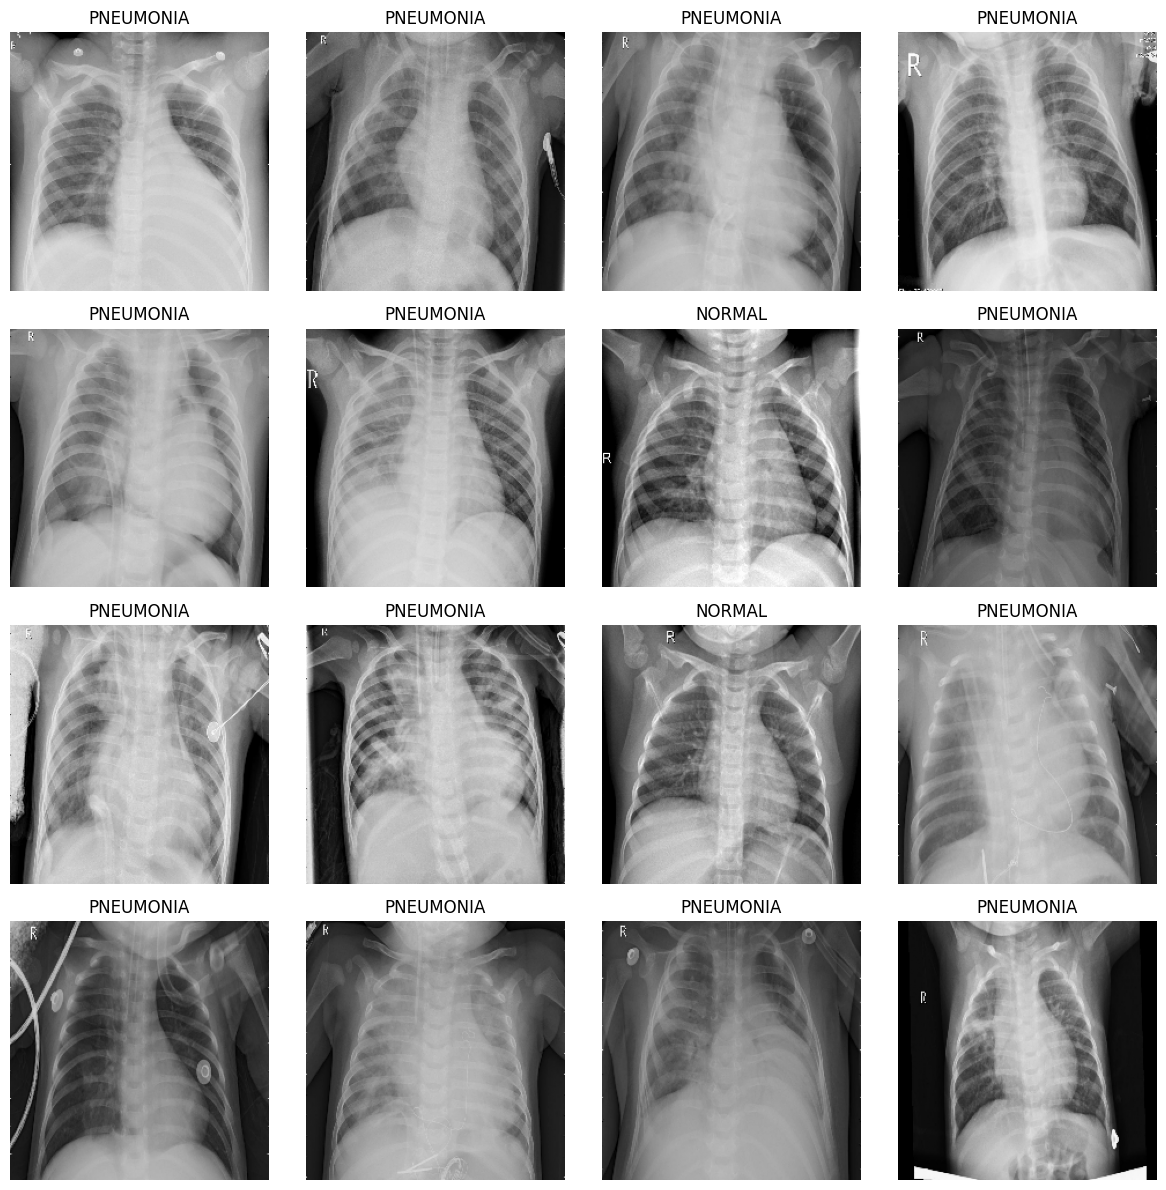

In [27]:
for images, labels in train_dataset.take(1):

    plt.figure(figsize=(12, 12))

    for i in range(16):
        plt.subplot(4, 4, i + 1)
        plt.imshow(images[i].numpy().astype("uint8")[..., 0], cmap="gray", vmin=0, vmax=255)
        plt.title(index_to_class[int(labels[i].numpy())])
        plt.axis("off")

    plt.tight_layout()
    plt.show()

**Observations**
- Images and labels line up correctly, and the X-rays are readable after resizing to 224 × 224.
- This batch contains 14 PNEUMONIA and 2 NORMAL images, which reflects the class imbalance of the training data.
- The images look stretched because of the non-aspect-preserving resize.
- Several images show markers, tubes or leads, in line with what was seen in section 3.6.

---
## 6. Data Augmentation

**What:** a small `Sequential` block of random transformations: `RandomRotation(0.05)` (about ±18°), `RandomZoom(0.1)` and `RandomTranslation(0.05, 0.05)`.

**Why:** augmentation increases the *variety* of the training data (not the number of samples) and helps the model cope with the differences in positioning and framing that were seen in the EDA.

The choices are deliberately conservative:
- **No horizontal flip.** A flipped chest X-ray puts the heart on the wrong side, which is not a realistic scan.
- **A smaller rotation range**, so images stay anatomically plausible.

These layers are part of the model, so they only act during training and are switched off automatically for evaluation and prediction.

In [28]:
data_augmentation = tf.keras.Sequential([    # Augmentation increases the variety of training data, not the number of samples.
    tf.keras.layers.RandomRotation(0.05),    # about ±18°
    tf.keras.layers.RandomZoom(0.1),
    tf.keras.layers.RandomTranslation(0.05, 0.05)
])

### 6.1 Previewing the Augmentation

**What:** apply the augmentation pipeline (`training=True`) to a batch and plot 16 results.

**Why:** confirms the transformations are subtle enough to keep the images realistic.

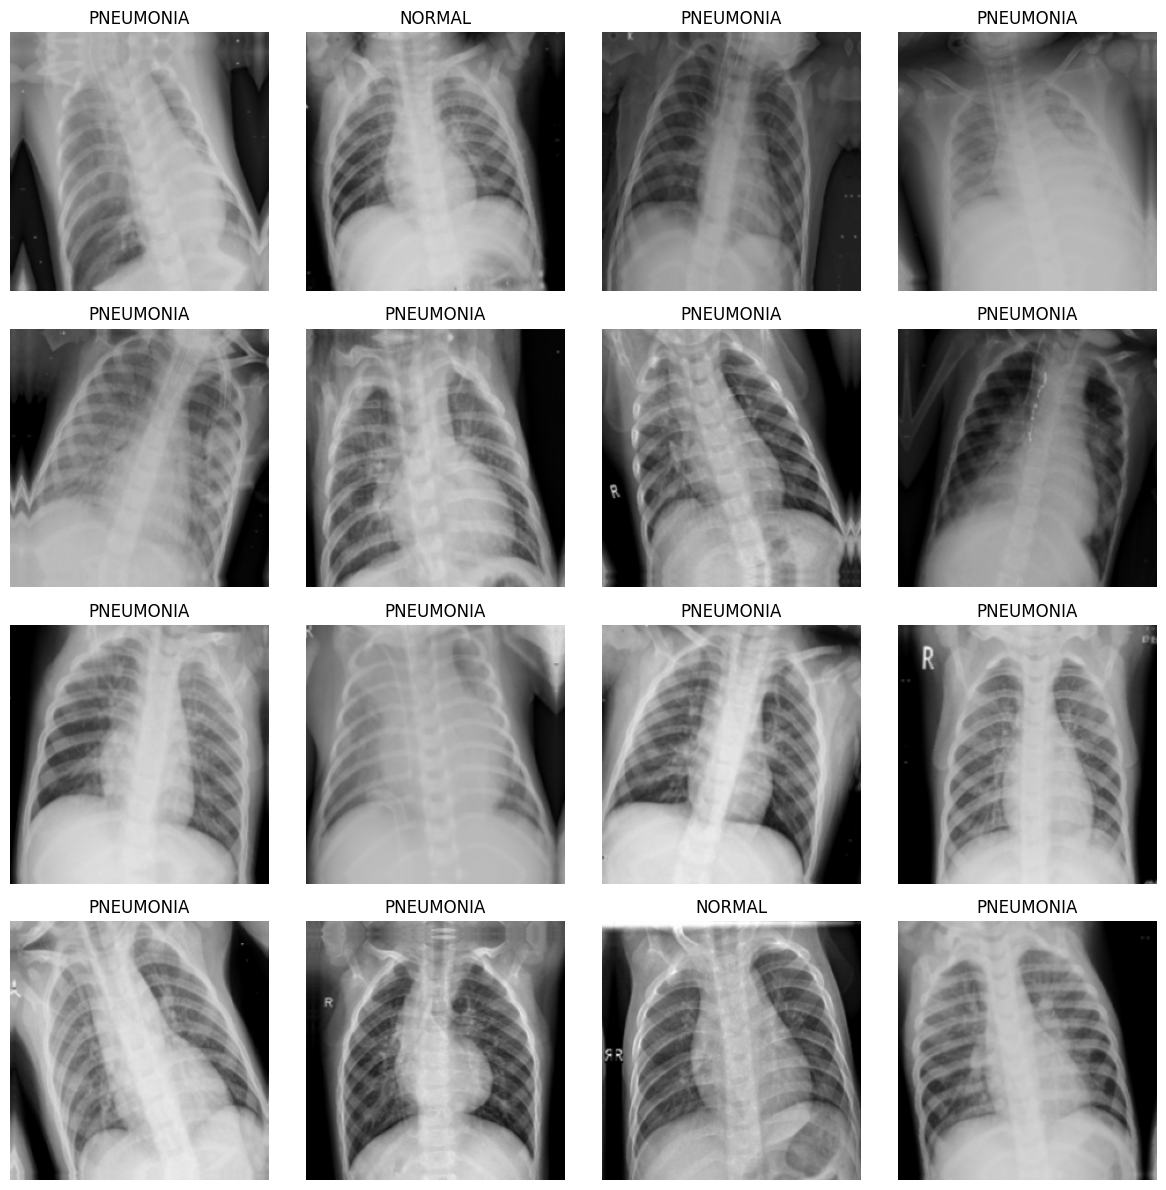

In [29]:
for images, labels in train_dataset.take(1):

    augmented_images = data_augmentation(images, training=True)

    plt.figure(figsize=(12, 12))

    for i in range(16):
        plt.subplot(4, 4, i + 1)
        plt.imshow(augmented_images[i].numpy().astype("uint8")[..., 0], cmap="gray", vmin=0, vmax=255)
        plt.title(index_to_class[int(labels[i].numpy())])
        plt.axis("off")

    plt.tight_layout()
    plt.show()

**Observations**
- The transformations are mild: small rotations, zoom and shifts, and the lungs stay clearly recognisable.
- Where an image is shifted or rotated, the empty border is filled by mirroring nearby pixels (the Keras default `reflect` fill), which shows as repeated bands at some edges.
- Labels are unchanged by augmentation.

---
## 7. Model Architecture

### 7.1 MobileNetV2 Transfer Learning with a 1-Channel Input

**Why transfer learning:** with about 5,000 training images, a CNN trained from scratch would have to learn all its visual features from little data. MobileNetV2 is a small network (about 2.3 M parameters in the backbone) already trained on ImageNet, so it starts with useful edge, texture and shape detectors.

**The grayscale problem:** the ImageNet weights of MobileNetV2 were trained on RGB, so only its **first conv layer** has a 3-channel kernel. To feed grayscale images we build the same network with a 1-channel input and copy every pretrained weight into it, **summing the first kernel over its RGB channels**. This gives exactly the same result as repeating the gray image 3 times, so we keep the pretrained features without storing or processing 3× the data.

**What the cell does:**
1. Loads the standard 3-channel ImageNet model (`rgb_base`), used only as a source of weights.
2. Builds the same architecture with a 1-channel input (`base_model`, `weights=None`).
3. Asserts both have the same number of layers, then copies weights layer by layer. Only `Conv1` changes shape: `(3, 3, 3, 32) → (3, 3, 1, 32)`.
4. Freezes the backbone with `base_model.trainable = False`, so only the new head is trained.

In [30]:
# 1) Standard 3-channel ImageNet model – used only as a source of pretrained weights
rgb_base = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SIZE + (3,),
    include_top=False,
    weights="imagenet"
)

# 2) Same architecture, but with a 1-channel (grayscale) input
base_model = tf.keras.applications.MobileNetV2(
    input_shape=IMG_SHAPE,
    include_top=False,
    weights=None
)

# 3) Copy the weights layer by layer; only the first conv kernel changes shape
assert len(rgb_base.layers) == len(base_model.layers)            #assert check both are same or not if not then it will stop programm and give error

for src_layer, dst_layer in zip(rgb_base.layers, base_model.layers):
    src_weights = src_layer.get_weights()

    if not src_weights:
        continue

    if src_layer.name == "Conv1":
        # kernel shape (3, 3, 3, 32) → (3, 3, 1, 32)
        src_weights[0] = src_weights[0].sum(axis=2, keepdims=True)

    dst_layer.set_weights(src_weights)

base_model.trainable = False

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


**Observations**
- The ImageNet weights file for MobileNetV2 without the classification top (about 9.4 MB) was downloaded.
- The assertion passed, which means both models have identical layer structure.

### 7.2 Sanity Check of the Weight Transfer

**What:** feed random values in [-1, 1] to the 1-channel model, and the same values repeated across 3 channels to the RGB model, then compare the outputs using the relative error.

**Why:** a wrong weight copy would not raise an error. The model would just perform badly. This test catches that early: a correct transfer gives a tiny error (floating-point rounding only), a wrong one gives an error near 1.

In [31]:
x_gray = np.random.uniform(-1, 1, size=(2,) + IMG_SHAPE).astype("float32")
x_rgb = np.repeat(x_gray, 3, axis=-1)

out_gray = base_model(x_gray, training=False).numpy()
out_rgb = rgb_base(x_rgb, training=False).numpy()

# relative error: ~1e-5 – 1e-4 when the transfer is correct (float rounding), ~1.0 when it is wrong
rel_error = np.abs(out_gray - out_rgb).max() / (np.abs(out_rgb).max() + 1e-12)

print("Output magnitude (max):", np.abs(out_rgb).max())
print("Relative error        :", rel_error)
assert rel_error < 1e-2, "Weight transfer failed"
print("Weight transfer OK ✔")

del rgb_base, x_gray, x_rgb        # no longer needed

Output magnitude (max): 6.0
Relative error        : 7.0730844e-06
Weight transfer OK ✔


**Observations**
- Relative error = **7.07 × 10⁻⁶**, far below the `1e-2` threshold used in the assertion.
- The assertion passed and printed "Weight transfer OK".
- The grayscale model is therefore equivalent to the RGB model on repeated-gray input.

### 7.3 Assembling the Full Model

**Layer by layer:**

| Layer | Purpose |
|---|---|
| `Input(224, 224, 1)` | Grayscale X-ray |
| `data_augmentation` | Random rotation, zoom and shift (training only) |
| `Rescaling(1/127.5, offset=-1)` | Maps pixels from [0, 255] to [-1, 1], the range MobileNetV2 expects |
| `base_model` (MobileNetV2, frozen) | Pretrained feature extractor, output `7 × 7 × 1280` |
| `GlobalAveragePooling2D` | Collapses each feature map to one value, giving a 1280-dim vector |
| `Dense(256, relu)` | Learns a task-specific combination of the features |
| `Dropout(0.3)` | Randomly drops 30% of units in training to reduce overfitting |
| `Dense(1, sigmoid)` | Outputs P(PNEUMONIA) |

Normalisation is done with a `Rescaling` layer instead of `mobilenet_v2.preprocess_input`. The maths is the same, but the saved `.keras` model can be reloaded without custom objects and accepts raw 0–255 pixels.

In [32]:
mobilenet_model = tf.keras.Sequential([

    tf.keras.layers.Input(
        shape=IMG_SHAPE
    ),

    data_augmentation,

    # Same maths as mobilenet_v2.preprocess_input (pixels → [-1, 1]),
    # but as a Rescaling layer so the saved .keras model reloads without custom objects
    tf.keras.layers.Rescaling(
        scale=1.0 / 127.5,
        offset=-1.0
    ),

    base_model,

    tf.keras.layers.GlobalAveragePooling2D(),

    tf.keras.layers.Dense(
        256,
        activation="relu"
    ),

    tf.keras.layers.Dropout(0.3),

    tf.keras.layers.Dense(
        1,
        activation="sigmoid"      # probability of class 1 = PNEUMONIA
    )
])
mobilenet_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential (Sequential)         │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,408 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,585,601 (9.86 MB)

 Trainable params: 328,193 (1.25 MB)

 Non-trainable params: 2,257,408 (8.61 MB)

**Observations**
- Total parameters: **2,585,601** (9.86 MB).
- Trainable: **328,193** (1.25 MB), about 12.7% of the model. These are the two `Dense` layers (327,936 + 257).
- Non-trainable: **2,257,408** (8.61 MB), the frozen MobileNetV2 backbone.
- The augmentation and rescaling layers have no parameters.
- The backbone output is `(None, 7, 7, 1280)`, which the pooling layer reduces to 1280 values per image.

---
## 8. Training

### 8.1 Compilation

| Setting | Choice | Reason |
|---|---|---|
| Optimizer | Adam, learning rate 0.001 | Robust default for training a new head |
| Loss | `binary_crossentropy` | Matches the single sigmoid output for two classes |
| Metrics | `accuracy`, `AUC` | Accuracy is easy to read; AUC does not depend on the 0.5 threshold and is more informative for imbalanced data |

In [36]:
mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=[
        "accuracy",
        tf.keras.metrics.AUC(name="auc")
    ]
)

### 8.2 Early Stopping

**What:** stop training when `val_loss` has not improved for **10 epochs** and restore the weights of the best epoch.

**Why:** it saves time and prevents the model from continuing to overfit. `restore_best_weights=True` means the final model is the best one seen, not the last one.

In [37]:
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=10,
    restore_best_weights=True
)

### 8.3 Model Training

**What:** train for up to 40 epochs with the class weights and the early-stopping callback.

> **Important:** `validation_data=test_dataset` is used here because the real validation folder has only 16 images, which is too small to evaluate on (as noted in the code comment). The consequence is that the **test set drives early stopping and the choice of the best epoch**. The final test metrics in section 11 are therefore not fully independent. Section 13 lists how to fix this.

In [38]:
history = mobilenet_model.fit(
    train_dataset,
    validation_data=test_dataset,           #the validation dataset size is too small to evaluate
    epochs=40,
    class_weight=class_weight,
    callbacks=[early_stopping]
)

Epoch 1/40
163/163 ━━━━━━━━━━━━━━━━━━━━ 47s 221ms/step - accuracy: 0.9327 - auc: 0.9836 - loss: 0.1629 - val_accuracy: 0.8269 - val_auc: 0.9572 - val_loss: 0.4352
Epoch 2/40
163/163 ━━━━━━━━━━━━━━━━━━━━ 32s 196ms/step - accuracy: 0.9436 - auc: 0.9883 - loss: 0.1367 - val_accuracy: 0.8462 - val_auc: 0.9668 - val_loss: 0.3656
Epoch 3/40
163/163 ━━━━━━━━━━━━━━━━━━━━ 34s 210ms/step - accuracy: 0.9542 - auc: 0.9912 - loss: 0.1174 - val_accuracy: 0.8942 - val_auc: 0.9635 - val_loss: 0.3171
Epoch 4/40
163/163 ━━━━━━━━━━━━━━━━━━━━ 37s 188ms/step - accuracy: 0.9561 - auc: 0.9909 - loss: 0.1174 - val_accuracy: 0.8558 - val_auc: 0.9595 - val_loss: 0.3668
Epoch 5/40
163/163 ━━━━━━━━━━━━━━━━━━━━ 31s 190ms/step - accuracy: 0.9590 - auc: 0.9922 - loss: 0.1076 - val_accuracy: 0.9054 - val_auc: 0.9601 - val_loss: 0.3002
Epoch 6/40
163/163 ━━━━━━━━━━━━━━━━━━━━ 41s 186ms/step - accuracy: 0.9528 - auc: 0.9912 - loss: 0.1162 - val_accuracy: 0.8862 - val_auc: 0.9605 - val_loss: 0.3085
Epoch 7/40
163/163 ━━━

**Observations**

Training stopped after **15 of the 40 epochs**. The best epoch was 5, and early stopping (patience 10) ended the run 10 epochs later.

| Epoch | Train acc | Train loss | Val acc | Val loss | Val AUC |
|---|---|---|---|---|---|
| 1 | 0.9327 | 0.1629 | 0.8269 | 0.4352 | 0.9572 |
| 5 (best) | 0.9590 | 0.1076 | 0.9054 | 0.3002 | 0.9601 |
| 15 (last) | 0.9663 | 0.0841 | 0.7997 | 0.7659 | 0.9380 |

- Training accuracy rises overall from 0.933 to 0.966 and training loss falls from 0.163 to 0.084.
- Validation accuracy is noisy across epochs. Validation loss is lowest at epoch 5 (0.3002) and then trends upward, reaching 0.7659 at epoch 15.
- Training and validation metrics diverge after epoch 5. This is a sign of **overfitting**, and it shows early stopping was doing its job.
- The model is already strong after one epoch (train accuracy 0.933), which reflects how useful the pretrained features are.
- Each epoch took roughly 30–47 s.
- Training metrics are computed with augmentation and dropout switched on, so they are not directly comparable to the validation numbers.

### 8.4 Best Epoch

**What:** find the epoch with the lowest validation loss.

**Why:** early stopping restored the weights of this epoch. Printing it makes clear which checkpoint the rest of the notebook uses.

In [39]:
best_epoch = np.argmin(history.history["val_loss"]) + 1

print("Best epoch:", best_epoch)
print("Best validation loss:", history.history["val_loss"][best_epoch - 1])
print("Best validation accuracy:", history.history["val_accuracy"][best_epoch - 1])

Best epoch: 5
Best validation loss: 0.30016443133354187
Best validation accuracy: 0.9054487347602844


**Observations**
- Best epoch: **5**, validation loss **0.3002**, validation accuracy **0.9054**.
- The model used from here on carries the weights of epoch 5.

---
## 9. Saving the Model

**What:** save the trained model in the native Keras format (`.keras`) and print the file size.

**Why:** the file contains the architecture, weights and training configuration, so the model can be reloaded for inference or deployment without re-training. Since normalisation is a built-in layer, no custom objects are needed at load time.

In [40]:
mobilenet_model.save("pneumonia_mobilenetv2.keras")

In [41]:
print(os.path.getsize("pneumonia_mobilenetv2.keras") / (1024 * 1024), "MB")

12.943288803100586 MB


**Observations**
- `pneumonia_mobilenetv2.keras` is **12.94 MB**, small enough for lightweight deployment.
- The file is written to the Colab runtime's working directory, which is temporary. Copy it to Drive or download it to keep it.

---
## 10. Training Curves

### 10.1 Training vs Validation Accuracy

**Why:** learning curves show how the model generalises. A widening gap between the two lines points to overfitting.

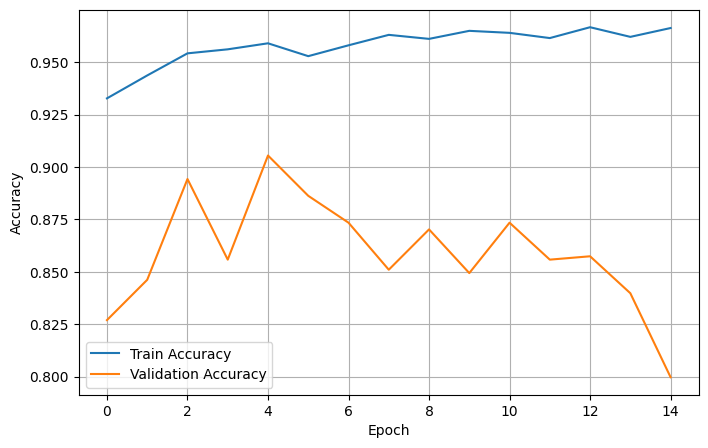

In [42]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()
plt.show()

**Observations**
- The x-axis starts at 0, so x = 4 is epoch 5.
- Training accuracy stays high and flat, roughly 0.93 to 0.97.
- Validation accuracy peaks at about 0.905 at epoch 5, then falls to about 0.80 by the final epoch.
- The gap between the two curves widens after epoch 5.

### 10.2 Training vs Validation Loss

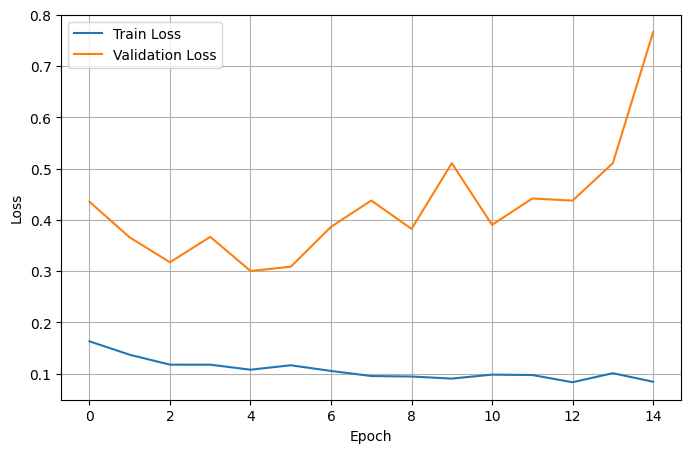

In [43]:
plt.figure(figsize=(8, 5))

plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()
plt.show()

**Observations**
- Training loss decreases from about 0.16 to about 0.08.
- Validation loss reaches its minimum of about 0.30 at epoch 5 and then rises, with a sharp jump to about 0.77 at the last epoch.
- Together with the accuracy plot, this supports stopping around epoch 5 and using the restored best weights.
- Part of the gap can also come from the different class mix in the training and evaluation data (section 4.4), not only from overfitting.

---
## 11. Model Evaluation

### 11.1 Loss, Accuracy and AUC on the Test Set

**What:** evaluate the restored model on `test_dataset`.

> **Note:** these numbers are identical to the best-epoch validation numbers in section 8.4 (loss 0.30016...). That is expected, because the test set was used as the validation set. The scores are therefore optimistic and should not be presented as an unbiased test result.

In [46]:
test_loss, test_accuracy, test_auc = mobilenet_model.evaluate(test_dataset)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)
print("Test AUC:", test_auc)

20/20 ━━━━━━━━━━━━━━━━━━━━ 4s 171ms/step - accuracy: 0.9054 - auc: 0.9601 - loss: 0.3002
Test Loss: 0.30016443133354187
Test Accuracy: 0.9054487347602844
Test AUC: 0.9600701332092285


**Observations**

| Metric | Value |
|---|---|
| Test loss | 0.3002 |
| Test accuracy | 0.9054 |
| Test AUC (Keras) | 0.9601 |

- Evaluation ran over 20 batches (624 images).
- Accuracy of about 90.5% and AUC of about 0.96 indicate that the model separates the two classes well on this data.

### 11.2 Generating Predictions

**What:** predict probabilities for the whole test set, then convert them to class labels with a 0.5 threshold. The true labels are read from `test_df`.

**Why:** the metrics below need the predictions as arrays. Because `test_dataset` is not shuffled, its order matches `test_df`, and the assertion checks that both arrays have the same length.

In [47]:
# test_dataset is not shuffled, so its order is identical to test_df
y_prob = mobilenet_model.predict(test_dataset, verbose=0).ravel()   # P(PNEUMONIA)

y_true = test_df["label"].values

# Sigmoid probability → binary class
y_pred = (y_prob >= 0.5).astype(int)

print("True labels shape:", y_true.shape)
print("Predicted labels shape:", y_pred.shape)

assert len(y_true) == len(y_pred), "Order mismatch between test_df and predictions"

True labels shape: (624,)
Predicted labels shape: (624,)


**Observations**
- 624 true labels and 624 predictions, so the alignment check passed.

### 11.3 Class Names

**What:** build the list of class names ordered by label index.

**Why:** reports and plots must show the names in the same order as the numeric labels (`0 = NORMAL`, `1 = PNEUMONIA`), otherwise the rows and columns of the reports would be swapped.

In [48]:
class_names = (
    train_df.sort_values("label")
    .drop_duplicates("label")["diagnosis"]
    .tolist()
)

print(len(class_names))
print(class_names)

2
['NORMAL', 'PNEUMONIA']


**Observations**
- `['NORMAL', 'PNEUMONIA']`, consistent with the label mapping from section 4.2.

### 11.4 Classification Report

**What:** precision, recall and F1-score for each class, plus overall accuracy and averages.

**Why:** accuracy alone hides how the model performs on each class, which matters here because the classes are imbalanced and their errors have different costs.

In [52]:
report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    zero_division=0
)

print(report)

              precision    recall  f1-score   support

      NORMAL       0.94      0.80      0.86       234
   PNEUMONIA       0.89      0.97      0.93       390

    accuracy                           0.91       624
   macro avg       0.91      0.89      0.90       624
weighted avg       0.91      0.91      0.90       624



**Observations**

| Class | Precision | Recall | F1 | Support |
|---|---|---|---|---|
| NORMAL | 0.94 | 0.80 | 0.86 | 234 |
| PNEUMONIA | 0.89 | 0.97 | 0.93 | 390 |
| Accuracy | | | 0.91 | 624 |
| Macro average | 0.91 | 0.89 | 0.90 | 624 |
| Weighted average | 0.91 | 0.91 | 0.90 | 624 |

- PNEUMONIA recall is high (0.97): the model finds almost all pneumonia cases.
- NORMAL recall is lower (0.80): about one in five healthy X-rays is flagged as pneumonia.
- The model is therefore tilted towards predicting PNEUMONIA, which is favourable for screening but produces false alarms.

### 11.5 Confusion Matrix

**What:** a heatmap of true versus predicted labels.

**Why:** it shows exactly which kinds of errors the model makes, not just how many.

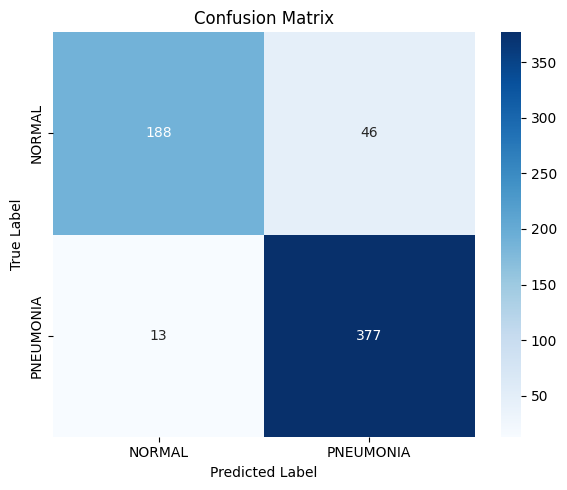

In [53]:
cm = confusion_matrix(y_true, y_pred, labels=[0, 1])

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names,
    annot=True,
    fmt="d"          # Show numbers as integers
)

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.tight_layout()
plt.show()

**Observations**

| | Predicted NORMAL | Predicted PNEUMONIA |
|---|---|---|
| **True NORMAL** | 188 | 46 |
| **True PNEUMONIA** | 13 | 377 |

- 565 of 624 images are correct (90.5%) and 59 are wrong.
- **46 false positives** (NORMAL predicted as PNEUMONIA) make up most of the errors.
- **13 false negatives** (PNEUMONIA predicted as NORMAL) are the smaller group.

### 11.6 Sensitivity and Specificity

For pneumonia screening the costly mistake is a **false negative** (sick patient predicted NORMAL), so sensitivity (recall of PNEUMONIA) is the number to watch.

**What:** derive the four confusion-matrix cells and compute sensitivity `TP / (TP + FN)` and specificity `TN / (TN + FP)`.

In [54]:
tn, fp, fn, tp = cm.ravel()

sensitivity = tp / (tp + fn)     # PNEUMONIA correctly found
specificity = tn / (tn + fp)     # NORMAL correctly found

print(f"True Negatives  (NORMAL → NORMAL)       : {tn}")
print(f"False Positives (NORMAL → PNEUMONIA)    : {fp}")
print(f"False Negatives (PNEUMONIA → NORMAL)    : {fn}")
print(f"True Positives  (PNEUMONIA → PNEUMONIA) : {tp}")
print()
print(f"Sensitivity (recall for PNEUMONIA): {sensitivity:.4f}")
print(f"Specificity (recall for NORMAL)   : {specificity:.4f}")

True Negatives  (NORMAL → NORMAL)       : 188
False Positives (NORMAL → PNEUMONIA)    : 46
False Negatives (PNEUMONIA → NORMAL)    : 13
True Positives  (PNEUMONIA → PNEUMONIA) : 377

Sensitivity (recall for PNEUMONIA): 0.9667
Specificity (recall for NORMAL)   : 0.8034


**Observations**

| Quantity | Value |
|---|---|
| True negatives | 188 |
| False positives | 46 |
| False negatives | 13 |
| True positives | 377 |
| **Sensitivity** | **0.9667** |
| **Specificity** | **0.8034** |

- The model catches about 96.7% of pneumonia cases and misses 13 out of 390.
- The price is a specificity of 80.3%: 46 of 234 healthy X-rays are flagged, which would mean extra follow-up work in practice.

### 11.7 ROC Curve

**What:** plot the true positive rate against the false positive rate across all decision thresholds, and compute the ROC-AUC with scikit-learn.

**Why:** unlike accuracy, the ROC curve does not depend on the 0.5 threshold. It shows the trade-off the model offers between catching pneumonia and raising false alarms.

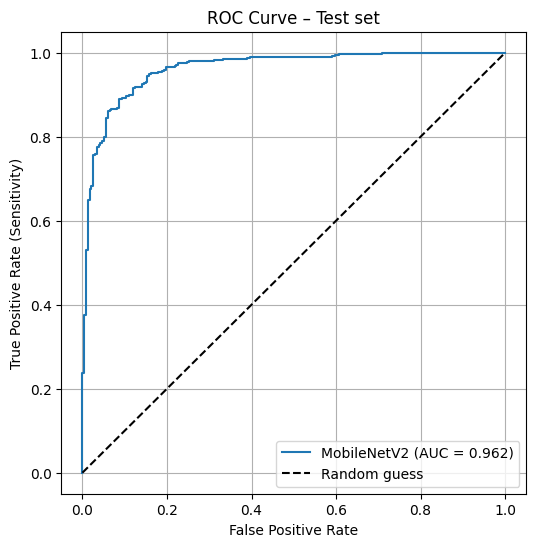

In [55]:
fpr, tpr, thresholds = roc_curve(y_true, y_prob)
auc_score = roc_auc_score(y_true, y_prob)

plt.figure(figsize=(6, 6))

plt.plot(fpr, tpr, label=f"MobileNetV2 (AUC = {auc_score:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Sensitivity)")
plt.title("ROC Curve – Test set")
plt.legend()
plt.grid()
plt.show()

**Observations**
- **AUC = 0.962**, far above the 0.5 of random guessing.
- The curve climbs steeply and stays near the top-left corner. At a false positive rate of about 0.2 the true positive rate is roughly 0.97.
- The Keras AUC in section 11.1 (0.9601) is slightly lower than this value. Keras approximates AUC over a fixed set of thresholds, while scikit-learn computes it exactly.
- The 0.5-threshold operating point (FPR ≈ 0.197, TPR ≈ 0.967) is one point on this curve. A different threshold would trade sensitivity against specificity.

---
## 12. Single-Image Inference

**What:** `predict_pneumonia(image_path)` runs one X-ray through the same steps as the training pipeline (read → grayscale → resize → float32), adds a batch dimension and calls the model. It converts the sigmoid probability into a class using the 0.5 threshold, reports the confidence of the predicted class and shows the image with the result.

**Why:** this is the simplest form of the deployment path: one image in, one label and confidence out. No manual normalisation is needed because `Rescaling` is part of the model.

In [56]:
def predict_pneumonia(image_path):
    image = tf.io.read_file(image_path)

    image = tf.image.decode_image(
        image,
        channels=1,
        expand_animations=False
    )

    image = tf.image.resize(image, IMG_SIZE)
    image = tf.cast(image, tf.float32)

    # (224, 224, 1) → (1, 224, 224, 1)
    image_batch = tf.expand_dims(image, axis=0)

    # Sigmoid output = P(PNEUMONIA)
    prediction = float(mobilenet_model.predict(image_batch, verbose=0)[0][0])

    # Convert probability to class
    predicted_index = 1 if prediction >= 0.5 else 0

    # Confidence of predicted class
    confidence = prediction if predicted_index == 1 else 1 - prediction
    confidence *= 100

    predicted_class = class_names[predicted_index]

    plt.figure(figsize=(5, 5))
    plt.imshow(image.numpy().astype("uint8")[..., 0], cmap="gray", vmin=0, vmax=255)

    plt.title(
        f"Class: {predicted_class}\n"
        f"Confidence: {confidence:.2f}%"
    )

    plt.axis("off")
    plt.show()

    return predicted_class, confidence

### 12.1 Example Prediction

The first PNEUMONIA image of the test set is used as a demo input.

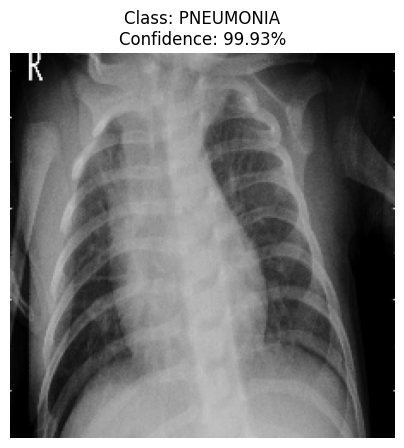

Predicted Class: PNEUMONIA
Confidence: 99.93%


In [57]:
# Pick any X-ray. Here: the first PNEUMONIA image of the test set.
image_path = test_df[test_df["diagnosis"] == "PNEUMONIA"]["image_path"].iloc[0]

diagnosis, confidence = predict_pneumonia(image_path)

print("Predicted Class:", diagnosis)
print(f"Confidence: {confidence:.2f}%")

**Observations**
- Prediction: **PNEUMONIA** with **99.93%** confidence, which is correct for this image.
- This is a single example from the set that was also used for validation, so it says little about overall performance. The metrics in section 11 are the better guide.

---
## 13. Conclusion

### 13.1 Summary

A MobileNetV2 model, transferred to grayscale input and trained with class weights, mild augmentation and early stopping, was built to classify chest X-rays as NORMAL or PNEUMONIA.

| Item | Result |
|---|---|
| Data | 5,856 images, 2 classes (train 5,216 / val 16 / test 624) |
| Model | MobileNetV2 backbone (frozen) + dense head, 2,585,601 parameters (328,193 trainable) |
| Training | Stopped after 15 epochs, best epoch 5 |
| Accuracy | 0.9054 |
| ROC-AUC | 0.962 |
| Sensitivity / Specificity | 0.9667 / 0.8034 |
| PNEUMONIA precision / recall / F1 | 0.89 / 0.97 / 0.93 |
| NORMAL precision / recall / F1 | 0.94 / 0.80 / 0.86 |
| Saved model size | 12.94 MB |

### 13.2 Key Findings

- The model detects pneumonia well: 377 of 390 cases were found (sensitivity 96.7%).
- Its weak point is specificity (80.3%): 46 healthy X-rays were flagged as pneumonia.
- Validation loss was lowest at epoch 5 and increased afterwards while training loss kept falling, so early stopping with restored weights was the right choice.
- The dataset is imbalanced (2.89 : 1) and its images vary widely in size, framing and contrast. Class weights, resizing to 224 × 224 and mild augmentation address this.

### 13.3 Limitations

- **The test set was used for validation.** `validation_data=test_dataset` guided early stopping and best-epoch selection, so the test scores are optimistic. The identical loss value in sections 8.4 and 11.1 confirms this.
- **The official validation split is tiny** (16 images), which is why the workaround above was used.
- **Single run.** Results come from one training run and one seed, so run-to-run variation is unknown.
 